In [1]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


In [2]:
import pandas as pd
pd.set_option('display.max_columns', 50)
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

from src.simulacion_cumulo import (
    ClusterSimulationConfig,
    OpenClusterSimulator,
)
from src.vector_director import run_cluster_analysis_from_dataframe
from src.proper_motion_simulator import simulate_proper_motions_from_3d_velocity
from src.utils import (
    show_cluster_validation_products_icrs,
    correct_gaia_proper_motions,
    plot_pm_vectors_on_sky,
    galactic_lb_to_unit_vectors,
)
from src.sky_apex_plotter import plot_cluster_motion_geometry

In [ ]:
# gráfica de cúmulo sintético de las hyades
config_hyades = ClusterSimulationConfig(
    n_members=455,

    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,
)
# ejecución de simulación del cúmulo sintético de las hyades
simulator_hyades = OpenClusterSimulator(config_hyades)
hyades_sintetico = simulator_hyades.simulate()
hyades_sintetico["cluster_id"] ="0_8"
hyades_sintetico["grupo"] = "1"
# ejecucion de cálculo de ápex para cúmulo sintético
result_hyades_sintetico = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
cluster_df = result_hyades_sintetico["data"]


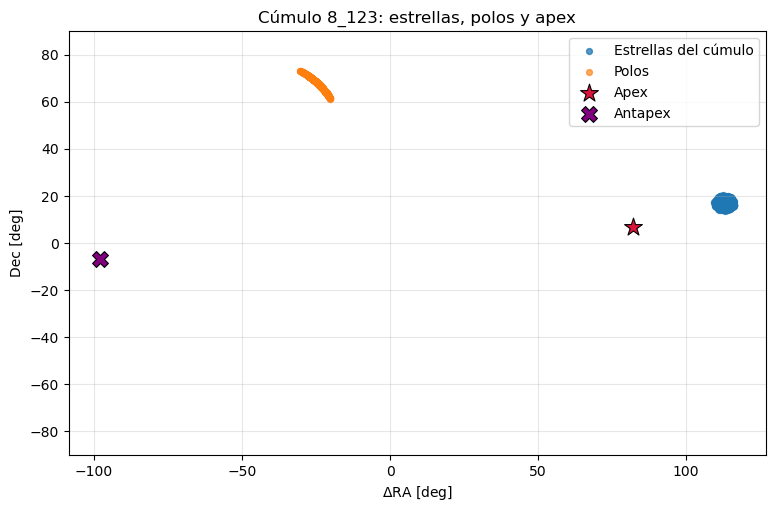

In [7]:
# 1. Gráfico plano RA-Dec
fig1 = plot_cluster_motion_geometry(
    cluster_df,
    analysis_result=result_hyades_sintetico,
    projection="radec",
    title="Cúmulo 8_123: estrellas, polos y apex",
)

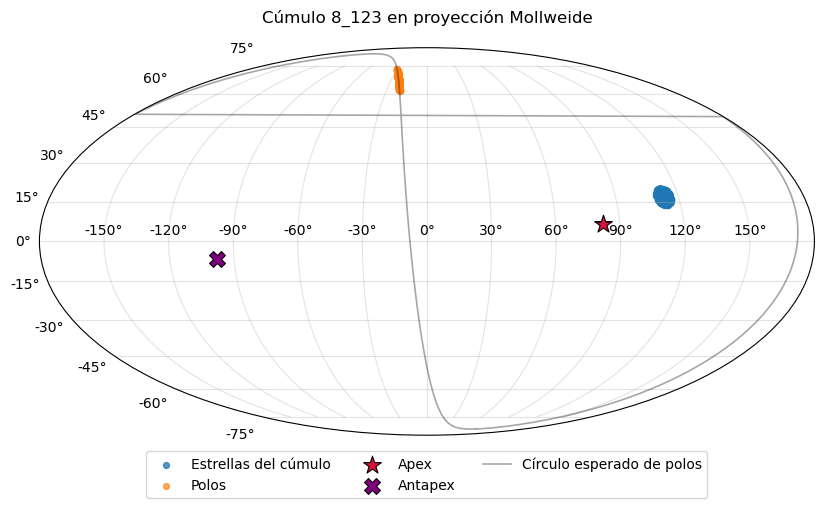

In [8]:
# 2. Proyección oval tipo mapa del mundo
fig2 = plot_cluster_motion_geometry(
    cluster_df,
    analysis_result=result_hyades_sintetico,
    projection="mollweide",
    title="Cúmulo 8_123 en proyección Mollweide",
    save_fig="cluster_8_123_mollweide.png",
)

In [12]:
# 3. Esfera interactiva
fig3 = plot_cluster_motion_geometry(
    cluster_df,
    analysis_result=result_hyades_sintetico,
    projection="sphere",
    title="Cúmulo 8 en esfera interactiva",
    save_html="cluster_8_123_sphere.html",
)

fig3.show()